# Inside FRC Team Software — A Data View

**63 teams · 5 seasons (2022–2026) · ~39k source files, parsed with tree-sitter into DuckDB.**

This notebook reads `data/code-index.duckdb` — a structural index of every San Diego
and national-survey FRC team's robot code, joined to their commit history and
[Statbotics](https://statbotics.io) EPA. It answers five questions:

1. **Seasonality** — *when* during the year does the software work actually happen?
2. **Frameworks** — what libraries do teams adopt, and how is adoption spreading?
3. **The rubric, automated** — candidate D1–D8 scores for all 63 teams, validated
   against the 24 hand-scored teams.
4. **Testing & simulation** — who invests in verification (the rarest markers)?
5. **Does better code win?** — code sophistication vs. competition results.

> **Caveats.** The index holds *declarations, imports, calls, annotations* and
> *deploy files* — not full call graphs. Public "daily-mirror" repos (6328, 254)
> publish **squashed** history, so seasonality/sustainability filter to repos with
> real history (`commits > 30`). Rubric scores here are **candidates** — the
> project's rule is *score what's used, confirm by reading.*

In [1]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.figsize": (9, 4.5), "font.size": 10})
ACC, ACC2, ACC3 = "#2563eb", "#f59e0b", "#10b981"

# Resolve the repo root by walking up from the kernel's cwd, so the notebook
# works whether it's launched from the repo root or from notebooks/.
def _root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "code-index.duckdb").exists():
            return base
    raise FileNotFoundError("data/code-index.duckdb not found — run `python3 main.py index-db`")
ROOT = _root()

con = duckdb.connect(str(ROOT / "data" / "code-index.duckdb"), read_only=True)
def q(sql): return con.execute(sql).df()

# Spearman = Pearson on ranks (avoids a scipy dependency).
def spearman(a, b): return a.rank().corr(b.rank())

# FRC competition calendar (month -> phase): build Jan–Feb, comp Mar–Apr, else offseason.
def phase(m): return "build" if m in (1, 2) else "competition" if m in (3, 4) else "offseason"

print("tables:", ", ".join(sorted(r[0] for r in con.execute("SHOW TABLES").fetchall())))
q('''SELECT (SELECT count(*) FROM teams) teams, (SELECT count(*) FROM repos) repos,
       (SELECT count(*) FROM files) files, (SELECT count(*) FROM symbols) symbols,
       (SELECT count(*) FROM calls) calls, (SELECT count(*) FROM commits) commits''')

tables: annotations, calls, commit_files, commits, deploy_files, epa, files, imports, repos, symbols, teams


,teams,repos,files,symbols,calls,commits
0,63,684,39688,629632,532934,123053


## 1 · The corpus at a glance

Two populations — the **national survey** teams (architectural reference set) and the
**San Diego** teams — de-duplicated by team number, plus a `library/` bucket for
season-independent code.

,national,san_diego,both
0,37,29,3


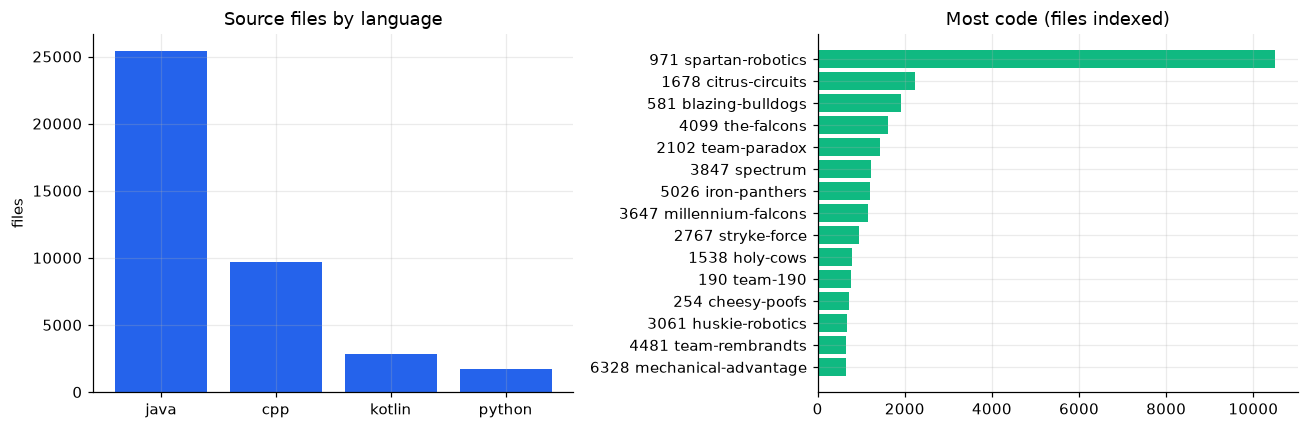

In [2]:
overview = q('''
SELECT
  count(DISTINCT team) FILTER (WHERE list_contains(sources,'national')) AS national,
  count(DISTINCT team) FILTER (WHERE list_contains(sources,'sandiego')) AS san_diego,
  count(DISTINCT team) FILTER (WHERE len(sources)=2)                    AS both
FROM teams''')
display(overview)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
lang = q("SELECT lang, count(*) files, sum(line_count) loc FROM files GROUP BY lang ORDER BY files DESC")
ax[0].bar(lang.lang, lang.files, color=ACC); ax[0].set_title("Source files by language"); ax[0].set_ylabel("files")
top = q('''SELECT t.team||' '||t.name AS team, count(*) files FROM files f JOIN teams t USING(team)
           GROUP BY 1 ORDER BY files DESC LIMIT 15''')
ax[1].barh(top.team[::-1], top.files[::-1], color=ACC3); ax[1].set_title("Most code (files indexed)")
plt.tight_layout(); plt.show()

## 2 · Seasonality of effort — *when* does the software get written?

Using the commit history of every real-history season repo, mapped onto the FRC
calendar: **build** (Jan–Feb), **competition** (Mar–Apr), **offseason** (May–Dec).

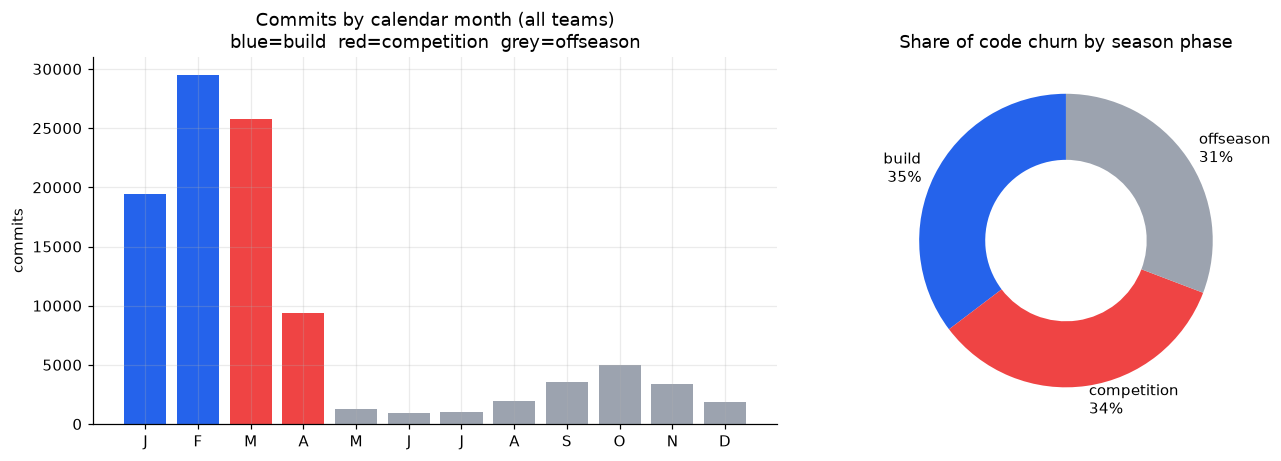

103,083 commits across 49 teams with real history


In [3]:
commits = q('''
SELECT c.committed_at, c.insertions + c.deletions AS churn, r.team, r.year
FROM commits c JOIN repos r ON r.repo_id = c.repo_id
WHERE r.bucket='season' AND r.commits > 30           -- drop squashed public mirrors
  AND c.committed_at IS NOT NULL
  AND extract(year FROM c.committed_at) BETWEEN 2021 AND 2026
''')
commits["month"] = commits.committed_at.dt.month
commits["phase"] = commits.month.map(phase)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
bym = commits.groupby("month").size().reindex(range(1, 13), fill_value=0)
colors = ["#2563eb" if m in (1,2) else "#ef4444" if m in (3,4) else "#9ca3af" for m in range(1,13)]
ax[0].bar(range(1, 13), bym.values, color=colors)
ax[0].set_xticks(range(1,13)); ax[0].set_xticklabels(list("JFMAMJJASOND"))
ax[0].set_title("Commits by calendar month (all teams)\nblue=build  red=competition  grey=offseason")
ax[0].set_ylabel("commits")

split = commits.groupby("phase").churn.sum().reindex(["build","competition","offseason"]).fillna(0)
ax[1].pie(split, labels=[f"{p}\n{v/split.sum():.0%}" for p,v in split.items()],
          colors=["#2563eb","#ef4444","#9ca3af"], startangle=90, wedgeprops=dict(width=.45))
ax[1].set_title("Share of code churn by season phase")
plt.tight_layout(); plt.show()
print(f"{len(commits):,} commits across {commits.team.nunique()} teams with real history")

**Front-loaded or last-minute?** A repo's *center of mass* is the average day-of-year
of its commits. Lower = work lands early; higher = late-season or offseason work.

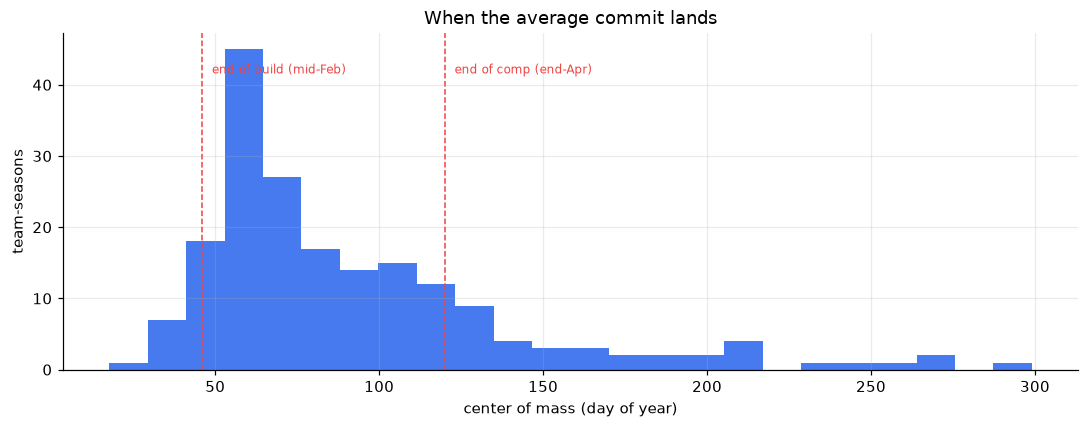

Most offseason-heavy team-seasons:


,team,name,year,center_doy,commits
0,9015,questionable-engineering,2022,299.0,37
1,2706,phantomcatz,2023,267.0,52
2,1678,citrus-circuits,2025,265.0,81
3,2984,vikings,2024,254.0,39
4,3128,aluminum-narwhals,2023,246.0,87
5,9730,metal-maniacs,2025,234.0,45
6,8891,wild-raccoons,2023,213.0,82
7,971,spartan-robotics,2025,212.0,440


In [4]:
com = q('''
SELECT r.team, t.name, r.year,
       avg(extract(doy FROM c.committed_at)) AS center_doy, count(*) AS commits
FROM commits c JOIN repos r ON r.repo_id=c.repo_id JOIN teams t ON t.team=r.team
WHERE r.bucket='season' AND r.commits>30 AND c.committed_at IS NOT NULL
GROUP BY r.team, t.name, r.year HAVING commits>30
''')
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(com.center_doy, bins=24, color=ACC, alpha=.85)
for d,l in [(46,"end of build (mid-Feb)"),(120,"end of comp (end-Apr)")]:
    ax.axvline(d, color="#ef4444", ls="--", lw=1); ax.text(d+3, ax.get_ylim()[1]*.88, l, fontsize=8, color="#ef4444")
ax.set_xlabel("center of mass (day of year)"); ax.set_ylabel("team-seasons")
ax.set_title("When the average commit lands")
plt.tight_layout(); plt.show()
print("Most offseason-heavy team-seasons:")
display(com.sort_values("center_doy", ascending=False).head(8).round(0).reset_index(drop=True))

## 3 · Framework adoption

From the `imports` table — the cleanest adoption signal.

,AdvantageKit,PathPlanner,Choreo,PhotonVision,maple-sim,DogLog,YAGSL
year,,,,,,,
2022,4,12,0,10,0,0,0
2023,11,33,0,24,0,0,0
2024,21,35,2,23,0,1,3
2025,19,34,16,28,12,2,8
2026,13,30,11,23,8,2,4


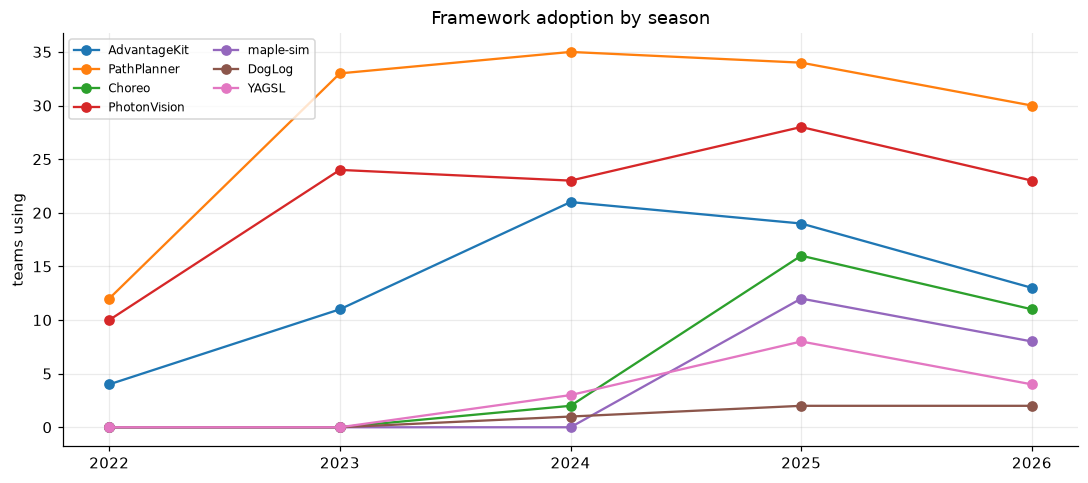

In [5]:
FRAMEWORKS = {
  "AdvantageKit":"org.littletonrobotics.junction%", "PathPlanner":"com.pathplanner%",
  "Choreo":"choreo%", "PhotonVision":"org.photonvision%", "maple-sim":"org.ironmaple%",
  "DogLog":"dev.doglog%", "YAGSL":"swervelib%",
}
sel = ",\n".join(f'''count(DISTINCT team) FILTER (WHERE target LIKE '{p}') AS "{n}"''' for n,p in FRAMEWORKS.items())
adopt = q(f"SELECT year, {sel} FROM imports WHERE year BETWEEN 2022 AND 2026 GROUP BY year ORDER BY year")
display(adopt.set_index("year"))

fig, ax = plt.subplots(figsize=(10, 4.5))
for n in FRAMEWORKS:
    ax.plot(adopt.year, adopt[n], marker="o", label=n)
ax.set_xticks(range(2022,2027)); ax.set_ylabel("teams using"); ax.set_title("Framework adoption by season")
ax.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

## 4 · The 8-dimension rubric, computed in SQL

Candidate D1–D8 for every team's latest season repo — the grep cheat-sheet across all
63 teams at once — validated against the 24 hand-scored teams in `sd-frc-master.csv`.

In [6]:
f_sym = q('''SELECT team,year,
  count(*) FILTER (WHERE kind='interface' AND name LIKE '%IO') io_iface,
  count(*) FILTER (WHERE kind='class' AND name LIKE '%IOSim') io_sim,
  count(*) FILTER (WHERE kind='class' AND (name LIKE '%IOReal' OR name LIKE '%IOTalonFX')) io_real,
  count(*) FILTER (WHERE name LIKE '%IONull' OR name LIKE '%IOReplay' OR name LIKE '%IdealSim') io_adv,
  count(*) FILTER (WHERE name LIKE '%ServoMotorSubsystem') servomotor,
  count(*) FILTER (WHERE name LIKE '%Superstructure' OR name LIKE '%RobotManager') coordinator,
  count(*) FILTER (WHERE kind='enum' AND (name LIKE '%WantedState' OR name LIKE '%SystemState')) fsm,
  count(*) FILTER (WHERE name LIKE '%AStarSolver' OR name LIKE '%BehaviorTree%') graph,
  count(*) FILTER (WHERE name='simulationPeriodic') sim_periodic,
  count(*) FILTER (WHERE name LIKE '%RobotState') robotstate,
  count(*) FILTER (WHERE name LIKE '%Repulsor') repulsor,
  count(*) FILTER (WHERE name LIKE '%FaultReporter') faultreporter,
  count(*) FILTER (WHERE name LIKE '%TunerConstants') tuner
  FROM symbols GROUP BY team,year''')
f_imp = q('''SELECT team,year,
  count(*) FILTER (WHERE target LIKE 'org.littletonrobotics.junction%') advantagekit,
  count(*) FILTER (WHERE target LIKE 'com.pathplanner%') pathplanner,
  count(*) FILTER (WHERE target LIKE 'choreo%') choreo,
  count(*) FILTER (WHERE target LIKE 'org.photonvision%') photon,
  count(*) FILTER (WHERE target LIKE 'org.ironmaple%') maple,
  count(*) FILTER (WHERE target LIKE 'dev.doglog%') doglog,
  count(*) FILTER (WHERE target LIKE '%epilogue%') epilogue,
  count(*) FILTER (WHERE target LIKE 'swervelib%') yagsl,
  count(*) FILTER (WHERE target LIKE '%wpilibj.simulation%') wpilib_sim,
  count(*) FILTER (WHERE target LIKE 'org.jgrapht%') jgrapht,
  count(*) FILTER (WHERE target LIKE 'org.junit%') junit,
  count(*) FILTER (WHERE target LIKE '%LimelightHelpers%') limelight,
  count(*) FILTER (WHERE target LIKE '%PoseEstimator%') poseest,
  count(*) FILTER (WHERE target LIKE '%TimeInterpolatableBuffer%') tib
  FROM imports GROUP BY team,year''')
f_call = q('''SELECT team,year,
  sum(n) FILTER (WHERE callee='addVisionMeasurement') addvision,
  sum(n) FILTER (WHERE callee='processInputs') processinputs,
  sum(n) FILTER (WHERE callee='assertEquals') asserts,
  sum(n) FILTER (WHERE callee='runToCompletion') runtocompletion,
  sum(n) FILTER (WHERE callee IN ('fromChoreoTrajectory','loadTrajectory')) choreo_used,
  sum(n) FILTER (WHERE callee LIKE 'put%') dashboard
  FROM calls GROUP BY team,year''')
f_ann = q('''SELECT team,year,
  sum(n) FILTER (WHERE name='AutoLog') AS autolog,
  sum(n) FILTER (WHERE name IN ('Logged','Epilogue')) AS logged,
  sum(n) FILTER (WHERE name='Test') AS test_ann
  FROM annotations GROUP BY team,year''')
f_dep = q('''SELECT team,year,
  count(*) FILTER (WHERE kind LIKE 'pathplanner%') AS pp_files,
  count(*) FILTER (WHERE kind='choreo') AS choreo_files,
  count(*) FILTER (WHERE kind='ci_workflow') AS ci,
  count(*) FILTER (WHERE kind='swerve_config') AS swerve
  FROM deploy_files GROUP BY team,year''')
f_file = q('''SELECT team,year, count(*) files, sum(line_count) loc,
  count(*) FILTER (WHERE file_path LIKE '%/test/%') test_files FROM files GROUP BY team,year''')

feat = f_file
for d in (f_sym, f_imp, f_call, f_ann, f_dep):
    feat = feat.merge(d, on=["team","year"], how="left")
feat = feat.fillna(0)

d8 = q('''SELECT team, count(DISTINCT year) FILTER (WHERE bucket='season') AS seasons,
                 max(contributors) AS contributors, bool_or(bucket='library') AS has_library
          FROM repos WHERE cloned GROUP BY team''')
ci_team = q("SELECT team, count(*) ci_any FROM deploy_files WHERE kind='ci_workflow' GROUP BY team")

# score each team on its latest real season repo (drop library-only / out-of-window teams)
seasonal = feat[feat.year.fillna(0) > 0]
latest = seasonal.sort_values("year").groupby("team", as_index=False).last()
latest = latest.merge(d8, on="team", how="left").merge(ci_team, on="team", how="left").fillna(0)
latest["year"] = latest.year.astype(int)
print(f"feature rows: {len(feat)}   teams scored (latest season): {len(latest)}")
latest.head(3)

feature rows: 260   teams scored (latest season): 55


,team,year,files,loc,test_files,io_iface,io_sim,io_real,io_adv,servomotor,...,logged,test_ann,pp_files,choreo_files,ci,swerve,seasons,contributors,has_library,ci_any
0,95,2026,38,12213.0,0,0,0,0,0,0,...,0.0,0.0,0.0,110.0,0.0,0.0,5,9,False,0.0
1,190,2026,300,33544.0,75,12,10,10,0,0,...,0.0,79.0,11.0,43.0,10.0,0.0,5,22,False,15.0
2,254,2025,168,31853.0,0,9,5,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,4,3,False,0.0


In [7]:
def lvl(*pairs):
    for cond, level in pairs:
        if cond: return level
    return 0

def score(r):
    # D1: ≥2 *IO interfaces is the IO-layer pattern (impls vary in name:
    # IOSim/IOReal, IOSparkMax/IOKraken, RealElevator/SimElevator, ...).
    D1 = lvl((r.servomotor>0 or r.io_adv>0, 4),
             (r.io_iface>=2, 3),
             (r.io_iface==1 or r.yagsl>0 or r.tuner>0, 2),
             (r.files>0, 1))
    D2 = lvl((r.graph>0 or r.jgrapht>0, 4), (r.coordinator>0, 3), (r.fsm>0, 2), (r.files>0, 1))
    D3 = lvl((r.io_adv>0, 4), (r.maple>0, 3),
             (r.wpilib_sim>0, 2), (r.sim_periodic>0, 1))
    D4 = lvl((r.runtocompletion>0 or (r.test_files>=10 and r.asserts>0), 4),
             (r.ci>0 and r.test_files>0, 3),
             (r.test_files>0 and (r.asserts>0 or r.test_ann>0), 2),
             (r.test_files>0 or r.test_ann>0, 1))
    D5 = lvl((r.faultreporter>0 or r.io_adv>0, 4), (r.advantagekit>0 and r.autolog>0, 3),
             (r.doglog>0 or r.logged>0 or r.epilogue>0, 2), (r.dashboard>0, 1))
    # D6: credit Choreo at L3 only when it is USED in code (fromChoreoTrajectory call), not when
    # .traj/.chor files merely exist — the agent study found ~15 teams ship Choreo files they never
    # drive (κ 0.60, the lowest-trust dimension). Files alone now cap at the PathPlanner rung.
    D6 = lvl((r.repulsor>0, 4), (r.choreo_used>0, 3),
             (r.pathplanner>0 or r.pp_files>0 or r.choreo_files>0, 2), (r.files>0, 1))
    # D7: L4 (world model) needs a RobotState whose pose lives in a TimeInterpolatableBuffer; a
    # RobotState class alone is L3-grade (still confirm filtering/std-devs by reading).
    D7 = lvl((r.robotstate>0 and r.tib>0, 4), (r.robotstate>0 or (r.photon>0 and r.addvision>0), 3),
             (r.poseest>0 or r.addvision>0, 2), (r.limelight>0, 1))
    D8 = lvl((r.seasons>=4 and r.has_library and r.ci_any>0, 4),
             (r.ci_any>0 and r.has_library, 3),
             (r.contributors>=5 or r.has_library, 2), (r.contributors>=2, 1))
    return pd.Series({"D1":D1,"D2":D2,"D3":D3,"D4":D4,"D5":D5,"D6":D6,"D7":D7,"D8":D8})

scores = latest.join(latest.apply(score, axis=1))
scores["cand_total"] = scores[[f"D{i}" for i in range(1,9)]].sum(axis=1)
scores = scores.merge(q("SELECT team, name FROM teams"), on="team")
sheet = scores[["team","name","year"]+[f"D{i}" for i in range(1,9)]+["cand_total"]].sort_values("cand_total", ascending=False)
print("Candidate rubric scoresheet (top 15 of 63) — automated, confirm by reading:")
display(sheet.head(15).reset_index(drop=True))

Candidate rubric scoresheet (top 15 of 63) — automated, confirm by reading:


,team,name,year,D1,D2,D3,D4,D5,D6,D7,D8,cand_total
0,3476,code-orange,2025,3,4,3,3,3,3,4,2,25
1,3015,ranger-robotics,2024,3,4,2,4,3,3,2,2,23
2,254,cheesy-poofs,2025,4,4,3,0,3,3,4,1,22
3,190,team-190,2026,3,1,2,4,3,3,3,2,21
4,3647,millennium-falcons,2025,2,3,3,0,3,3,3,4,21
5,2706,phantomcatz,2026,4,3,4,0,4,2,1,2,20
6,5026,iron-panthers,2026,3,3,3,0,3,2,4,2,20
7,581,blazing-bulldogs,2026,2,3,2,4,2,1,4,2,20
8,1678,citrus-circuits,2026,4,3,2,3,1,2,3,2,20
9,2910,jack-in-the-bot,2026,4,2,3,0,3,2,3,2,19


**Does the automated pass agree with the human scores?** Merge candidate totals with
the 24 hand-scored San Diego teams and correlate.

24 teams in both. Spearman correlation, candidate vs hand:


,dimension,spearman
0,D1,0.47
1,D2,0.67
2,D3,0.68
3,D4,1.00
4,D5,0.60
5,D6,0.36
6,D7,0.44
7,D8,0.63
8,Total,0.65


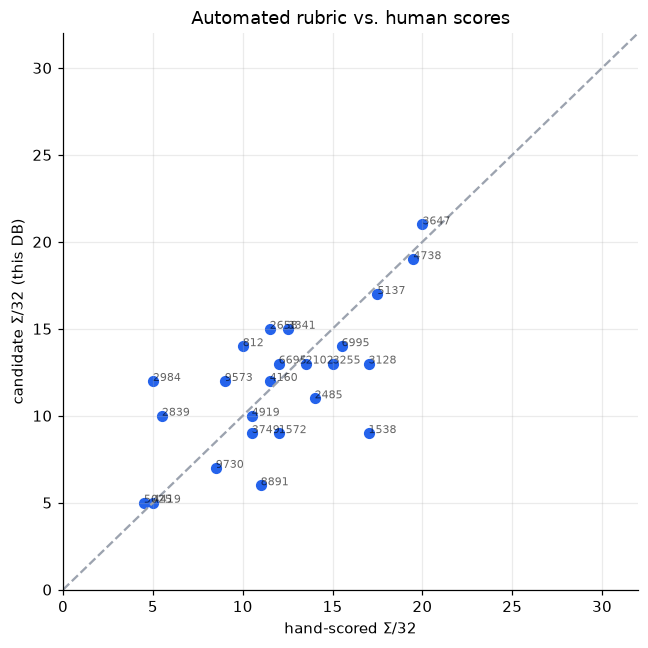

In [8]:
hand = pd.read_csv(ROOT / "knowledge/survey/sd-frc-master.csv")
hand["team"] = hand.team.astype(int)
ren = {c: c+"_h" for c in [f"D{i}" for i in range(1,9)]+["Total"]}
hd = hand[["team"]+[f"D{i}" for i in range(1,9)]+["Total"]].rename(columns=ren)
val = scores.merge(hd, on="team")
print(f"{len(val)} teams in both. Spearman correlation, candidate vs hand:")
perdim = pd.DataFrame({
  "dimension":[f"D{i}" for i in range(1,9)]+["Total"],
  "spearman":[spearman(val[f"D{i}"], val[f"D{i}_h"]) for i in range(1,9)]
             +[spearman(val["cand_total"], val["Total_h"])]}).round(2)
display(perdim)

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(val.Total_h, val.cand_total, color=ACC, s=40)
for _,r in val.iterrows(): ax.annotate(int(r.team), (r.Total_h, r.cand_total), fontsize=7, alpha=.6)
ax.plot([0,32],[0,32],"--",color="#9ca3af"); ax.set_xlim(0,32); ax.set_ylim(0,32)
ax.set_xlabel("hand-scored Σ/32"); ax.set_ylabel("candidate Σ/32 (this DB)")
ax.set_title("Automated rubric vs. human scores"); plt.tight_layout(); plt.show()

## 5 · Testing & simulation — the rarest markers

D4 (testing) is the sharpest discriminator and barely correlates with winning — a pure
engineering-culture signal. The rubric's flag: **"architecture without verification"** —
a clean IO layer (D1≥3) with no tests (D4≤1).

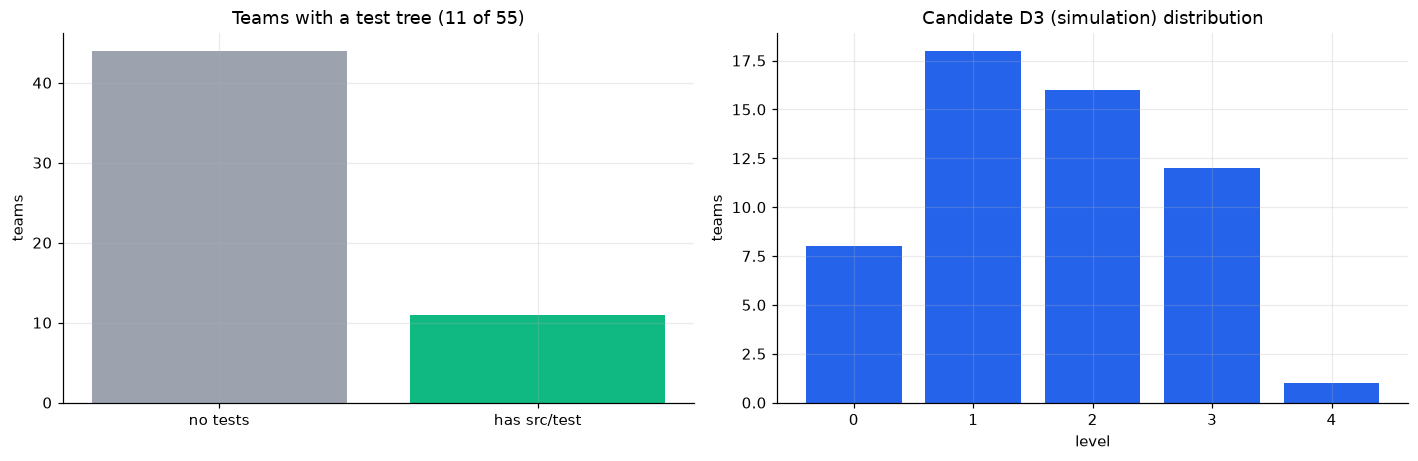

⚑ Architecture-without-verification — IO layer but no tests (14 teams):


,team,name,D1,D4,D3,test_files
0,254,cheesy-poofs,4,0,3,0
1,2706,phantomcatz,4,0,4,0
2,2910,jack-in-the-bot,4,0,3,0
3,1114,simbotics,3,0,3,0
4,1257,parallel-universe,3,0,2,0
5,2767,stryke-force,3,0,0,0
6,3061,huskie-robotics,3,0,2,0
7,3636,team-3636,3,0,3,0
8,4099,the-falcons,3,0,3,0
9,4481,team-rembrandts,3,0,2,0


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
n_tests = int((scores.test_files>0).sum())
ax[0].bar(["no tests","has src/test"], [len(scores)-n_tests, n_tests], color=["#9ca3af",ACC3])
ax[0].set_title(f"Teams with a test tree ({n_tests} of {len(scores)})"); ax[0].set_ylabel("teams")
sim = scores.D3.value_counts().sort_index()
ax[1].bar(sim.index.astype(str), sim.values, color=ACC)
ax[1].set_title("Candidate D3 (simulation) distribution"); ax[1].set_xlabel("level"); ax[1].set_ylabel("teams")
plt.tight_layout(); plt.show()

flag = scores[(scores.D1>=3) & (scores.D4<=1)][["team","name","D1","D4","D3","test_files"]]
print(f"⚑ Architecture-without-verification — IO layer but no tests ({len(flag)} teams):")
display(flag.sort_values("D1", ascending=False).reset_index(drop=True))

## 6 · Does better code win?

Candidate scores joined to season-matched Statbotics EPA. The original 24-team hand-scored
study found Σ vs normalized EPA ≈ 0.55. Recomputed here on **candidate** scores across a
broader, more elite sample (55 teams incl. the national set), the link is weaker and the
per-dimension ranking shifts — a reminder that automated candidates ≠ confirmed scores, and
that the national elites have strong code *and* strong EPA, compressing the relationship.

55 teams with code+EPA in their latest season.


,rho_normEPA,rho_winrate
dimension,,
D1,0.32,0.26
D2,0.23,0.21
D3,0.17,0.11
D4,0.20,0.10
D5,0.32,0.22
D6,0.18,0.25
D7,0.32,0.30
D8,-0.00,-0.02
cand_total,0.38,0.31


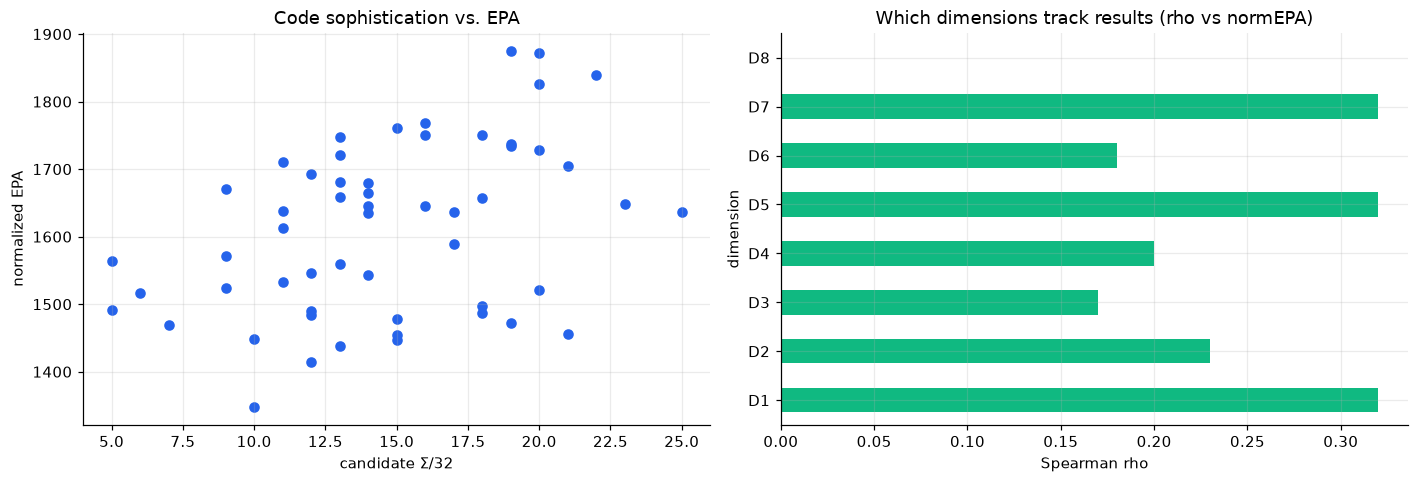

In [10]:
epa = q("SELECT team, year, norm_epa, winrate FROM epa WHERE status='ok'")
ce = scores.merge(epa, on=["team","year"], how="inner")
print(f"{len(ce)} teams with code+EPA in their latest season.")
rows=[]
for d in [f"D{i}" for i in range(1,9)]+["cand_total"]:
    rows.append({"dimension":d,
                 "rho_normEPA": spearman(ce[d], ce.norm_epa),
                 "rho_winrate": spearman(ce[d], ce.winrate)})
corr = pd.DataFrame(rows).set_index("dimension").round(2)
display(corr)

fig, ax = plt.subplots(1,2, figsize=(13,4.5))
ax[0].scatter(ce.cand_total, ce.norm_epa, color=ACC, s=35)
ax[0].set_xlabel("candidate Σ/32"); ax[0].set_ylabel("normalized EPA"); ax[0].set_title("Code sophistication vs. EPA")
corr["rho_normEPA"].drop("cand_total").plot(kind="barh", ax=ax[1], color=ACC3)
ax[1].set_title("Which dimensions track results (rho vs normEPA)"); ax[1].set_xlabel("Spearman rho")
plt.tight_layout(); plt.show()

## 7 · Per-team profile

A reusable card: rubric vector, frameworks, and EPA for any team.

In [11]:
def profile(team):
    r = scores[scores.team==team]
    if r.empty: return print("no data for", team)
    r = r.iloc[0]
    fw = [n for n,c in [("AdvantageKit",r.advantagekit),("PathPlanner",r.pathplanner),("Choreo",r.choreo),
          ("PhotonVision",r.photon),("maple-sim",r.maple),("DogLog",r.doglog),("YAGSL",r.yagsl)] if c>0]
    e = epa[epa.team==team].sort_values("year")
    print(f"-- {team} {r['name']}  (latest season {int(r.year)}) --")
    print("  rubric:", "  ".join(f"D{i}={r[f'D{i}']:g}" for i in range(1,9)), f"  total={r.cand_total:g}/32")
    print("  frameworks:", ", ".join(fw) or "-")
    print("  tests:", "yes" if r.test_files>0 else "no", "| sim:", "yes" if r.sim_periodic>0 else "no",
          "| IO interfaces:", int(r.io_iface))
    if not e.empty:
        print("  EPA:", "  ".join(f"{int(y)}:{int(n)}" for y,n in zip(e.year,e.norm_epa)))

for t in [254, 1155, 4738, 3128]:
    profile(t); print()

-- 254 cheesy-poofs  (latest season 2025) --
  rubric: D1=4  D2=4  D3=3  D4=0  D5=3  D6=3  D7=4  D8=1   total=22/32
  frameworks: AdvantageKit, PathPlanner, PhotonVision, maple-sim
  tests: no | sim: yes | IO interfaces: 9
  EPA: 2022:1941  2023:1887  2024:1876  2025:1840  2026:1950

-- 1155 sciborgs  (latest season 2026) --
  rubric: D1=3  D2=1  D3=2  D4=4  D5=2  D6=2  D7=3  D8=2   total=19/32
  frameworks: PathPlanner, Choreo, PhotonVision
  tests: yes | sim: yes | IO interfaces: 9
  EPA: 2022:1479  2023:1490  2024:1592  2025:1530  2026:1472

-- 4738 patribots  (latest season 2025) --
  rubric: D1=3  D2=3  D3=2  D4=0  D5=3  D6=2  D7=2  D8=4   total=19/32
  frameworks: AdvantageKit, PathPlanner
  tests: no | sim: yes | IO interfaces: 7
  EPA: 2022:1572  2023:1722  2024:1697  2025:1735  2026:1575

-- 3128 aluminum-narwhals  (latest season 2025) --
  rubric: D1=1  D2=3  D3=0  D4=0  D5=1  D6=2  D7=2  D8=4   total=13/32
  frameworks: PathPlanner
  tests: no | sim: no | IO interfaces: 0
  

---
*Generated by `scripts/build_notebook.py` from `data/code-index.duckdb`
(`python3 main.py index-db`). Candidate rubric scores are automated signals — confirm
by reading the cited files before reporting a team's score.*